<a href="https://colab.research.google.com/github/Noelsip/flood-bpn-smd/blob/main/Flood_AutoML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi Anomali Banjir dengan Isolation Forest per Kota

Notebook ini memakai dataset yang sama (`processed/dataset_timeseries.csv`), tetapi implementasinya difokuskan ke **unsupervised anomaly detection**. Model utama adalah **Isolation Forest**, bukan supervised classifier.

Perubahan metodologi utama:
- model dilatih terpisah untuk **Balikpapan** dan **Samarinda**;
- setiap kota punya train/test split kronologis sendiri;
- `StandardScaler` dan `IsolationForest` hanya di-fit pada train fold kota tersebut;
- test fold hanya di-transform dan diberi `anomaly_score` serta `is_anomaly`;
- `is_anomaly = 1` diinterpretasikan sebagai **anomali cuaca** yang kemudian dievaluasi terhadap banjir 1-3 hari ke depan;
- tidak ada FLAML, Random Forest, XGBoost, CatBoost, SMOTE, confusion matrix, atau classification report.


## 0. Clone Repository (Google Colab)
Saat berjalan di Colab, isi `REPO_URL` dengan repository yang berisi dataset dan folder `scripts/`.

In [12]:
import os
import sys
import subprocess

REPO_URL = "https://github.com/Noelsip/flood-bpn-smd.git"

def in_colab():
    return "google.colab" in sys.modules

if in_colab():
    repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(repo_dir)
    print("Direktori kerja:", os.getcwd())
else:
    print("Bukan Colab: memakai repository lokal.")


Direktori kerja: /content/flood-bpn-smd/flood-bpn-smd


## 1. Dependensi
Hanya dependensi inti yang dibutuhkan untuk deteksi anomali tabular.

In [13]:
if in_colab():
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scikit-learn", "matplotlib"
    ], check=True)
    print("Dependensi terpasang.")
else:
    print("Bukan Colab: pastikan requirements.txt sudah terpasang.")


Dependensi terpasang.


## 2. Import Library dan Konfigurasi

In [14]:
from pathlib import Path
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts.isolation_forest_per_city as ifpc
ifpc = importlib.reload(ifpc)

DEFAULT_CITIES = ifpc.DEFAULT_CITIES
DEFAULT_OPERATIONAL_TOP_RATE = ifpc.DEFAULT_OPERATIONAL_TOP_RATE
TARGET = ifpc.TARGET
attach_kecamatan_prior = ifpc.attach_kecamatan_prior
evaluate_anomaly_overlap = ifpc.evaluate_anomaly_overlap
feature_columns = ifpc.feature_columns
run_per_city_isolation_forest = ifpc.run_per_city_isolation_forest
save_outputs = ifpc.save_outputs

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
ANOMALY_CONTAMINATION = 0.05
TRAIN_RATIO = 0.80
SPLIT_MODE = "chronological_per_city"
OPERATIONAL_TOP_RATE = DEFAULT_OPERATIONAL_TOP_RATE
MAX_KECAMATAN_PER_ALERT = 3

ROOT = Path.cwd()
DATA_PATH = ROOT / "processed" / "dataset_timeseries.csv"
OUT_DIR = ROOT / "outputs"
CLEAN_DIR = ROOT / "clean"
OUT_DIR.mkdir(exist_ok=True)

print("Dataset:", DATA_PATH)
print("Output :", OUT_DIR)


Dataset: /content/flood-bpn-smd/flood-bpn-smd/processed/dataset_timeseries.csv
Output : /content/flood-bpn-smd/flood-bpn-smd/outputs


## 3. Pemuatan Dataset
Dataset tetap sama. Data kota luar tidak dipakai untuk melatih model utama karena revisi memilih model yang belajar pola normal **per kota**. Split dilakukan secara kronologis di dalam tiap kota: 80% observasi awal menjadi train dan 20% observasi terbaru menjadi test.

In [15]:
data = pd.read_csv(DATA_PATH, parse_dates=["time"])
city_data = data[data["city"].isin(DEFAULT_CITIES)].copy()
CITY_LABEL_MAP = {
    "Kota Balikpapan": "Balikpapan",
    "Kota Samarinda": "Samarinda",
}
data["city"]      = data["city"].replace(CITY_LABEL_MAP)
city_data["city"] = city_data["city"].replace(CITY_LABEL_MAP)

# Update DEFAULT_CITIES supaya filter dan loop per kota tetap jalan
DEFAULT_CITIES = ["Balikpapan", "Samarinda"]

features = feature_columns(city_data)

print("All dataset:", data.shape)
print("Kaltim:", city_data.shape)
print("Numerik feature sum:", len(features))
print("Split mode:", SPLIT_MODE, "| train ratio:", TRAIN_RATIO)
print("Operational anomaly flag: top", int(OPERATIONAL_TOP_RATE * 100), "% anomaly_score by city")
print("IF without cal/:", [c for c in features if c in ["doy_sin", "doy_cos", "month_sin", "month_cos", "rain7_pctl", "precip7_pctl", "soil7_pctl"]])
print("City:", city_data["city"].unique().tolist())

if "split" in city_data.columns:
    display(city_data.groupby(["split", "city"])[TARGET].agg(hari="count", banjir_historis="sum"))
else:
    display(city_data.groupby("city")[TARGET].agg(hari="count", banjir_historis="sum"))


All dataset: (21570, 68)
Kaltim: (6418, 68)
Numerik feature sum: 56
Split mode: chronological_per_city | train ratio: 0.8
Operational anomaly flag: top 5 % anomaly_score by city
IF without cal/: []
City: ['Samarinda', 'Balikpapan']


hari  banjir_historis
split city                             
test  Balikpapan   643                3
      Samarinda    641               27
train Balikpapan  2566               36
      Samarinda   2568               86

## 4. Eksplorasi Singkat
Bagian ini hanya deskriptif. Label historis banjir boleh ditampilkan sebagai konteks data, tetapi tidak dipakai untuk melatih Isolation Forest.

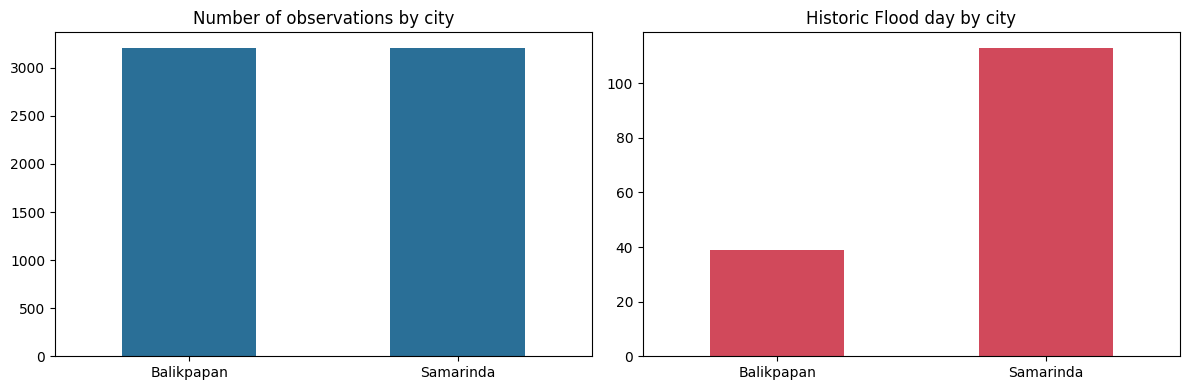

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
city_data.groupby("city").size().plot.bar(ax=ax[0], color="#2A6F97", rot=0)
ax[0].set_title("Number of observations by city")
ax[0].set_xlabel("")

if TARGET in city_data.columns:
    city_data.groupby("city")[TARGET].sum().plot.bar(ax=ax[1], color="#D1495B", rot=0)
    ax[1].set_title("Historic Flood day by city")
    ax[1].set_xlabel("")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()


## 5. Isolation Forest per Kota
Setiap kota diproses sendiri. Di dalam tiap kota, data diurutkan berdasarkan waktu: 80% observasi awal menjadi train dan 20% observasi terbaru menjadi test. Scaler dan Isolation Forest hanya fit pada fitur train fold kota itu, sedangkan label banjir historis tidak dipakai untuk fitting model.

In [17]:
summary_df, anomaly_df, city_results = run_per_city_isolation_forest(
    city_data,
    cities=DEFAULT_CITIES,
    contamination=ANOMALY_CONTAMINATION,
    train_ratio=TRAIN_RATIO,
    split_mode=SPLIT_MODE,
    operational_top_rate=OPERATIONAL_TOP_RATE,
    random_state=SEED,
)

kecamatan_df = attach_kecamatan_prior(
    anomaly_df,
    CLEAN_DIR,
    max_per_city=MAX_KECAMATAN_PER_ALERT,
    anomalies_only=True,
)
evaluation_df = evaluate_anomaly_overlap(anomaly_df)
save_outputs(summary_df, anomaly_df, OUT_DIR, kecamatan_df, evaluation_df)

summary_view = summary_df.copy()
for col in ["train_start", "train_end", "test_start", "test_end"]:
    summary_view[col] = pd.to_datetime(summary_view[col]).dt.date

display(summary_view)
print("Output disimpan:")
print("-", OUT_DIR / "isolation_forest_summary_per_city.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_all.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_balikpapan.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_samarinda.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_kecamatan.csv")
print("-", OUT_DIR / "isolation_forest_overlap_evaluation.csv")


,city,split_mode,operational_top_rate,train_days,test_days,train_start,train_end,test_start,test_end,detected_anomaly,anomaly_rate,model_detected_anomaly,model_anomaly_rate,mean_anomaly_score,max_anomaly_score,historical_flood_days,anomaly_on_historical_flood,model_anomaly_on_historical_flood
0,Balikpapan,chronological_per_city,0.0500,2567,642,2016-07-29,2023-08-08,2023-08-09,2025-05-11,33,0.0514,274,0.4268,0.4913,0.6154,3,0,0
1,Samarinda,chronological_per_city,0.0500,2567,642,2016-07-29,2023-08-08,2023-08-09,2025-05-11,33,0.0514,297,0.4626,0.4954,0.6314,30,1,7


Output disimpan:
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_summary_per_city.csv
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_anomaly_all.csv
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_anomaly_balikpapan.csv
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_anomaly_samarinda.csv
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_anomaly_kecamatan.csv
- /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_overlap_evaluation.csv


## 6. Evaluasi Post-hoc per Kota
Evaluasi dipisah per kota dan tidak memakai confusion matrix. Flag operasional `is_anomaly` memakai top 5% skor anomali per kota agar jumlah anomali tetap proporsional. Label banjir historis hanya dipakai setelah model menghasilkan skor, untuk melihat overlap dan posisi hari banjir dalam ranking skor anomali.

In [18]:
cols = [
    "city", "test_days", "detected_anomaly", "anomaly_rate",
    "model_detected_anomaly", "model_anomaly_rate",
    "mean_anomaly_score", "max_anomaly_score",
    "historical_flood_days", "anomaly_on_historical_flood",
]
display(summary_df[cols].round(4))

print("Overlap dan ranking anomaly score terhadap banjir historis:")
display(evaluation_df.round(4))
evaluation_df.to_csv(OUT_DIR / "isolation_forest_overlap_evaluation.csv", index=False)

for city, result in city_results.items():
    top = result.test.sort_values("anomaly_score", ascending=False).head(10)
    show_cols = [
        col for col in [
            "city", "time", "anomaly_score", "anomaly_rank", "anomaly_score_percentile",
            "model_is_anomaly", "top_5pct_anomaly", "is_anomaly", "flood_anomaly", "anomaly_interpretation",
            TARGET, "rain", "precip", "soil", "rain_roll7_sum", "precip_roll7_sum", "soil_roll7_mean",
        ] if col in top.columns
    ]
    print(f"Top anomali test - {city}")
    display(top[show_cols])


,city,test_days,detected_anomaly,anomaly_rate,model_detected_anomaly,model_anomaly_rate,mean_anomaly_score,max_anomaly_score,historical_flood_days,anomaly_on_historical_flood
0,Balikpapan,642,33,0.0514,274,0.4268,0.4913,0.6154,3,0
1,Samarinda,642,33,0.0514,297,0.4626,0.4954,0.6314,30,1


Overlap dan ranking anomaly score terhadap banjir historis:


,city,test_days,historical_flood_days,anomaly_days,anomaly_rate,flood_days_flagged,overlap_rate,mean_score_flood_days,mean_score_non_flood_days,top_1pct_days,top_1pct_flood_hits,top_1pct_hit_rate,top_5pct_days,top_5pct_flood_hits,top_5pct_hit_rate,top_10pct_days,top_10pct_flood_hits,top_10pct_hit_rate
0,Balikpapan,642,3,33,0.0514,0,0.0000,0.4588,0.4915,7,0,0.0000,33,0,0.0000,65,0,0.0000
1,Samarinda,642,30,33,0.0514,1,0.0333,0.4698,0.4967,7,0,0.0000,33,1,0.0333,65,3,0.1000


Top anomali test - Balikpapan


,city,time,anomaly_score,anomaly_rank,anomaly_score_percentile,model_is_anomaly,top_5pct_anomaly,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
26,Balikpapan,2023-09-04,0.6154,1,1.0000,1,1,1,1,anomali cuaca,0,0.6000,0.6000,0.2900,7.7000,7.7000,0.2974
27,Balikpapan,2023-09-05,0.6121,2,0.9984,1,1,1,1,anomali cuaca,0,0.7000,0.7000,0.2880,6.6000,6.6000,0.2957
28,Balikpapan,2023-09-06,0.6116,3,0.9969,1,1,1,1,anomali cuaca,0,2.6000,2.6000,0.2870,6.0000,6.0000,0.2940
25,Balikpapan,2023-09-03,0.6089,4,0.9953,1,1,1,1,anomali cuaca,0,1.6000,1.6000,0.2920,7.1000,7.1000,0.2993
23,Balikpapan,2023-09-01,0.6050,5,0.9938,1,1,1,1,anomali cuaca,0,0.5000,0.5000,0.2960,24.3000,24.3000,0.3016
29,Balikpapan,2023-09-07,0.6027,6,0.9922,1,1,1,1,anomali cuaca,0,2.0000,2.0000,0.2880,7.3000,7.3000,0.2923
22,Balikpapan,2023-08-31,0.6014,7,0.9907,1,1,1,1,anomali cuaca,0,0.7000,0.7000,0.2980,32.7000,32.7000,0.3007
24,Balikpapan,2023-09-02,0.5992,8,0.9891,1,1,1,1,anomali cuaca,0,0.6000,0.6000,0.2950,16.8000,16.8000,0.3010
487,Balikpapan,2024-12-08,0.5977,9,0.9875,1,1,1,1,anomali cuaca,0,8.1000,8.1000,0.2100,78.1000,78.1000,0.2340
32,Balikpapan,2023-09-10,0.5975,10,0.9860,1,1,1,1,anomali cuaca,0,0.0000,0.0000,0.2850,9.2000,9.2000,0.2887


Top anomali test - Samarinda


,city,time,anomaly_score,anomaly_rank,anomaly_score_percentile,model_is_anomaly,top_5pct_anomaly,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
539,Samarinda,2025-01-29,0.6314,1,1.0000,1,1,1,1,anomali cuaca,0,16.6000,16.6000,0.3440,212.7000,212.7000,0.3030
504,Samarinda,2024-12-25,0.6286,2,0.9984,1,1,1,1,anomali cuaca,0,2.0000,2.0000,0.2320,76.1000,76.1000,0.2359
538,Samarinda,2025-01-28,0.6282,3,0.9969,1,1,1,1,anomali cuaca,0,55.6000,55.6000,0.3360,168.4000,168.4000,0.2929
469,Samarinda,2024-11-20,0.6262,4,0.9953,1,1,1,1,anomali cuaca,0,7.7000,7.7000,0.2640,130.2000,130.2000,0.2393
503,Samarinda,2024-12-24,0.6252,5,0.9938,1,1,1,1,anomali cuaca,0,16.3000,16.3000,0.2300,59.8000,59.8000,0.2386
470,Samarinda,2024-11-21,0.6229,6,0.9922,1,1,1,1,anomali cuaca,0,4.1000,4.1000,0.2630,132.8000,132.8000,0.2436
501,Samarinda,2024-12-22,0.6226,7,0.9907,1,1,1,1,anomali cuaca,0,30.8000,30.8000,0.2360,32.7000,32.7000,0.2404
540,Samarinda,2025-01-30,0.6223,8,0.9891,1,1,1,1,anomali cuaca,0,3.0000,3.0000,0.3410,216.0000,216.0000,0.3134
505,Samarinda,2024-12-26,0.6185,9,0.9875,1,1,1,1,anomali cuaca,0,0.1000,0.1000,0.2250,77.2000,77.2000,0.2344
502,Samarinda,2024-12-23,0.6171,10,0.9860,1,1,1,1,anomali cuaca,0,1.6000,1.6000,0.2370,62.0000,62.0000,0.2394


## 7. Visualisasi Skor Anomali
Grafik memperlihatkan distribusi skor pada test fold masing-masing kota dan garis ambang empiris yang memisahkan data normal/anomali menurut model.

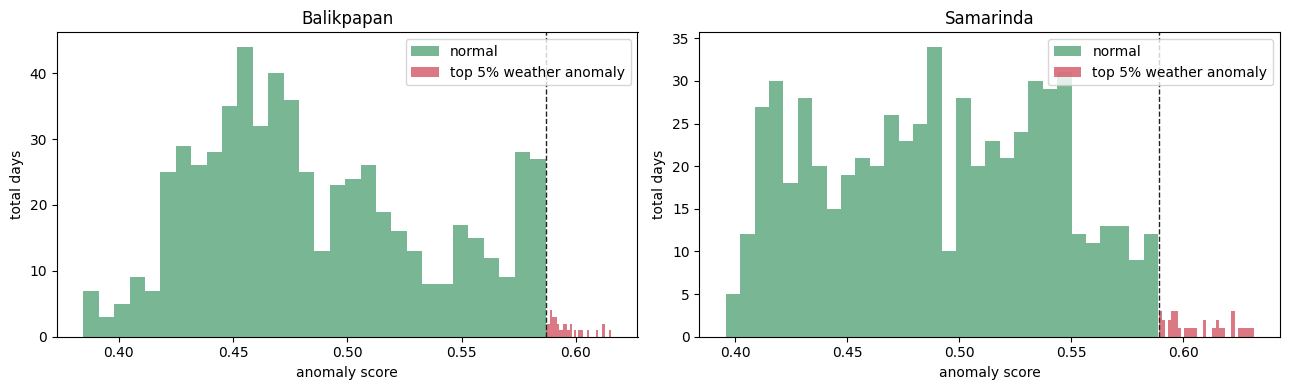

In [19]:
fig, axes = plt.subplots(1, len(city_results), figsize=(13, 4), squeeze=False)
for ax, (city, result) in zip(axes.ravel(), city_results.items()):
    test = result.test.copy()
    normal = test[test["is_anomaly"] == 0]
    anomaly = test[test["is_anomaly"] == 1]
    ax.hist(normal["anomaly_score"], bins=30, alpha=0.75, label="normal", color="#4C9F70")
    ax.hist(anomaly["anomaly_score"], bins=30, alpha=0.75, label="top 5% weather anomaly", color="#D1495B")
    if not anomaly.empty:
        ax.axvline(anomaly["anomaly_score"].min(), color="#222222", linestyle="--", linewidth=1)
    ax.set_title(city)
    ax.set_xlabel("anomaly score")
    ax.set_ylabel("total days")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Visualisasi Hubungan Skor Anomali dan Banjir Historis
Visualisasi ini menunjukkan apakah hari banjir historis cenderung berada pada skor anomali tinggi.


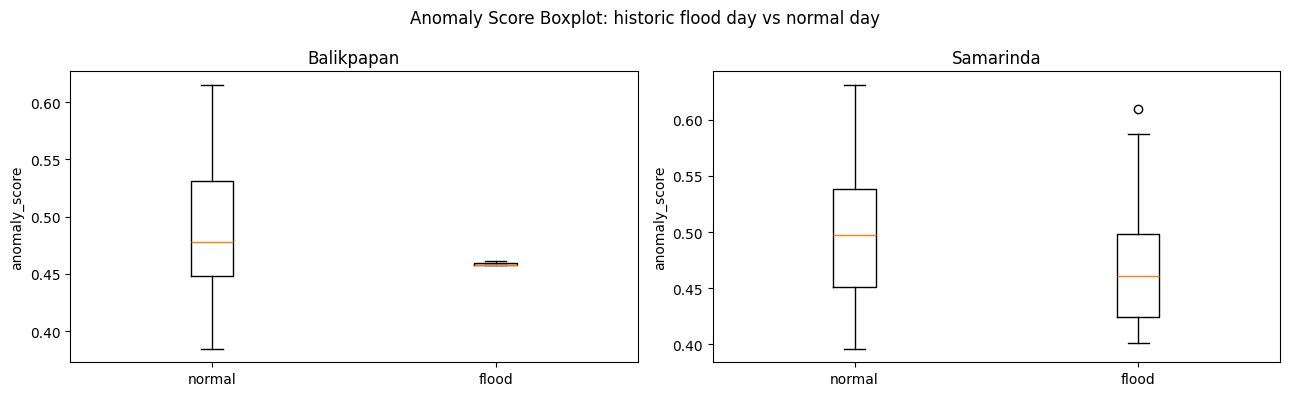

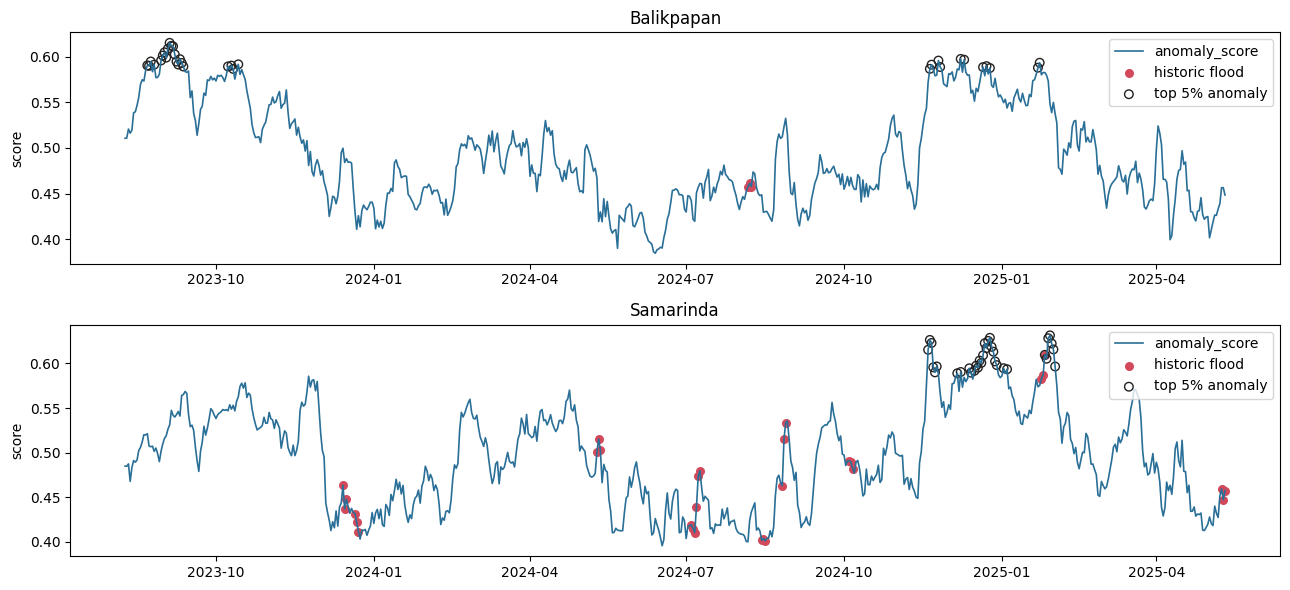

In [20]:
fig, axes = plt.subplots(1, len(city_results), figsize=(13, 4), squeeze=False)
for ax, (city, result) in zip(axes.ravel(), city_results.items()):
    test = result.test.copy()
    groups = [
        test.loc[test[TARGET] == 0, "anomaly_score"],
        test.loc[test[TARGET] == 1, "anomaly_score"],
    ]
    ax.boxplot(groups, labels=["normal", "flood"])
    ax.set_title(city)
    ax.set_ylabel("anomaly_score")
plt.suptitle("Anomaly Score Boxplot: historic flood day vs normal day")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(city_results), 1, figsize=(13, 6), sharex=False)
if len(city_results) == 1:
    axes = [axes]
for ax, (city, result) in zip(axes, city_results.items()):
    test = result.test.sort_values("time")
    ax.plot(test["time"], test["anomaly_score"], color="#2A6F97", linewidth=1.2, label="anomaly_score")
    flood_days = test[test[TARGET] == 1]
    ax.scatter(flood_days["time"], flood_days["anomaly_score"], color="#D1495B", s=30, label="historic flood")
    top_days = test[test["is_anomaly"] == 1]
    ax.scatter(top_days["time"], top_days["anomaly_score"], facecolors="none", edgecolors="#222222", s=38, label="top 5% anomaly")
    ax.set_title(city)
    ax.set_ylabel("score")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 8. Output Akhir
`is_anomaly = 1` adalah flag operasional untuk 5% hari dengan skor anomali tertinggi pada setiap kota. Hasil ini dievaluasi secara post-hoc terhadap `Flood_next_3d` untuk melihat apakah anomali cuaca berhubungan dengan potensi banjir 1-3 hari ke depan. Kecamatan hanya dilampirkan pada output anomali sebagai prior lokasi historis dari `clean/banjir_*.csv`; kolom ini tidak digunakan untuk training model.

In [21]:
output_cols = [
    col for col in [
        "city", "time", "anomaly_score", "is_anomaly", "flood_anomaly", "anomaly_interpretation",
        TARGET, "rain", "precip", "soil", "rain_roll3_sum", "rain_roll7_sum", "rain_roll14_sum",
        "precip_roll3_sum", "precip_roll7_sum", "soil_roll3_mean", "soil_roll7_mean",
    ] if col in anomaly_df.columns
]
final_output = anomaly_df[output_cols].sort_values(["city", "time"]).reset_index(drop=True)
final_kecamatan_cols = [
    col for col in [
        "city", "time", "kecamatan", "banjir_historis", "anomaly_score", "anomaly_rank",
        "model_is_anomaly", "top_5pct_anomaly", "is_anomaly",
        "flood_anomaly", "anomaly_interpretation", TARGET, "rain", "precip", "soil",
        "rain_roll7_sum", "precip_roll7_sum", "soil_roll7_mean",
    ] if col in kecamatan_df.columns
]
final_kecamatan = kecamatan_df[final_kecamatan_cols].sort_values(
    ["city", "time", "banjir_historis"], ascending=[True, True, False]
).reset_index(drop=True)

display(final_output.head(20))
print("Output anomali + prior kecamatan:")
display(final_kecamatan.head(30))

final_output.to_csv(OUT_DIR / "isolation_forest_final_output.csv", index=False)
final_kecamatan.to_csv(OUT_DIR / "isolation_forest_final_output_kecamatan.csv", index=False)
print("Disimpan:", OUT_DIR / "isolation_forest_final_output.csv")
print("Disimpan:", OUT_DIR / "isolation_forest_final_output_kecamatan.csv")


,city,time,anomaly_score,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll3_sum,rain_roll7_sum,rain_roll14_sum,precip_roll3_sum,precip_roll7_sum,soil_roll3_mean,soil_roll7_mean
0,Balikpapan,2023-08-09,0.5106,0,0,normal,0,1.1000,1.1000,0.3170,4.2000,11.5000,26.5000,4.2000,11.5000,0.3243,0.3291
1,Balikpapan,2023-08-10,0.5109,0,0,normal,0,1.4000,1.4000,0.3160,4.7000,10.4000,26.8000,4.7000,10.4000,0.3207,0.3266
2,Balikpapan,2023-08-11,0.5208,0,0,normal,0,4.2000,4.2000,0.3140,3.3000,8.8000,25.9000,3.3000,8.8000,0.3180,0.3241
3,Balikpapan,2023-08-12,0.5163,0,0,normal,0,1.7000,1.7000,0.3130,6.7000,12.0000,26.3000,6.7000,12.0000,0.3157,0.3216
4,Balikpapan,2023-08-13,0.5195,0,0,normal,0,0.0000,0.0000,0.3120,7.3000,12.6000,25.3000,7.3000,12.6000,0.3143,0.3190
5,Balikpapan,2023-08-14,0.5387,0,0,normal,0,0.5000,0.5000,0.3070,5.9000,12.0000,24.3000,5.9000,12.0000,0.3130,0.3167
6,Balikpapan,2023-08-15,0.5397,0,0,normal,0,1.5000,1.5000,0.3060,2.2000,9.7000,22.1000,2.2000,9.7000,0.3107,0.3143
7,Balikpapan,2023-08-16,0.5467,0,0,normal,0,0.1000,0.1000,0.3010,2.0000,10.4000,21.9000,2.0000,10.4000,0.3083,0.3121
8,Balikpapan,2023-08-17,0.5556,0,0,normal,0,1.8000,1.8000,0.2970,2.1000,9.4000,19.8000,2.1000,9.4000,0.3047,0.3099
9,Balikpapan,2023-08-18,0.5697,0,0,normal,0,0.9000,0.9000,0.2950,3.4000,9.8000,18.6000,3.4000,9.8000,0.3013,0.3071


Output anomali + prior kecamatan:


,city,time,kecamatan,banjir_historis,anomaly_score,anomaly_rank,model_is_anomaly,top_5pct_anomaly,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
0,Balikpapan,2023-08-22,NaN,NaN,0.5906,22,1,1,1,1,anomali cuaca,0,1.1000,1.1000,0.2910,6.1000,6.1000,0.2963
1,Balikpapan,2023-08-23,NaN,NaN,0.5901,24,1,1,1,1,anomali cuaca,0,3.0000,3.0000,0.2890,5.7000,5.7000,0.2941
2,Balikpapan,2023-08-24,NaN,NaN,0.5949,14,1,1,1,1,anomali cuaca,0,9.1000,9.1000,0.2920,8.6000,8.6000,0.2924
3,Balikpapan,2023-08-26,NaN,NaN,0.5914,20,1,1,1,1,anomali cuaca,0,10.3000,10.3000,0.3070,23.0000,23.0000,0.2924
4,Balikpapan,2023-08-30,NaN,NaN,0.5961,12,1,1,1,1,anomali cuaca,0,1.3000,1.3000,0.2990,34.4000,34.4000,0.2993
5,Balikpapan,2023-08-31,NaN,NaN,0.6014,7,1,1,1,1,anomali cuaca,0,0.7000,0.7000,0.2980,32.7000,32.7000,0.3007
6,Balikpapan,2023-09-01,NaN,NaN,0.6050,5,1,1,1,1,anomali cuaca,0,0.5000,0.5000,0.2960,24.3000,24.3000,0.3016
7,Balikpapan,2023-09-02,NaN,NaN,0.5992,8,1,1,1,1,anomali cuaca,0,0.6000,0.6000,0.2950,16.8000,16.8000,0.3010
8,Balikpapan,2023-09-03,NaN,NaN,0.6089,4,1,1,1,1,anomali cuaca,0,1.6000,1.6000,0.2920,7.1000,7.1000,0.2993
9,Balikpapan,2023-09-04,NaN,NaN,0.6154,1,1,1,1,1,anomali cuaca,0,0.6000,0.6000,0.2900,7.7000,7.7000,0.2974


Disimpan: /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_final_output.csv
Disimpan: /content/flood-bpn-smd/flood-bpn-smd/outputs/isolation_forest_final_output_kecamatan.csv


---
## Catatan Metodologi
- Pendekatan ini adalah **unsupervised anomaly detection**, bukan supervised flood classification.
- Model dilatih **terpisah per kota** agar pola normal Balikpapan dan Samarinda tidak dicampur.
- Untuk setiap kota, data dibagi secara kronologis 80/20, lalu `StandardScaler.fit()` dan `IsolationForest.fit()` hanya memakai train fold kota tersebut.
- Test fold hanya dipakai untuk menghasilkan skor anomali; flag operasional memakai top 5% skor tertinggi per kota.
- Evaluasi dilakukan secara post-hoc melalui overlap dan ranking skor anomali terhadap catatan banjir historis, bukan confusion matrix.
- Kecamatan pada output adalah prior lokasi historis per kota, bukan hasil training atau fitur model.
- Tidak ada confusion matrix karena output utama bukan prediksi supervised terhadap kelas banjir, melainkan deteksi outlier/anomali cuaca yang dievaluasi terhadap banjir 1-3 hari ke depan secara post-hoc.
